In [1]:
from __future__ import annotations
from typing import Iterable

class Value:
  def __init__(
      self,
      data: float = 0.0,
      label: str = '',
      op: str = '',
      children: list[Value] = None,
      grad: float = 0.0,
  ) -> None:
    self.data = float(data)
    self.label = label
    self.op = op
    self.children = [] if children is None else children
    self.grad = grad
  
  def __repr__(self) -> str:
    return f'{self.__class__.__name__}({self.__dict__})'

  def forward(self) -> float:
    if len(self.children) == 0:
      return self.data

    if self.op == '+':
      self.data = sum(child.forward() for child in self.children)
      return self.data
    
    elif self.op == '*':
      def multiply(iterable: Iterable) -> float:
        result = 1
        for element in iterable:
          result *= element
        return result
      self.data = multiply(child.forward() for child in self.children)
      return self.data
    
    else:
      raise NotImplementedError(f'operation not implemented: {self.op}')
    
  def backward(self) -> None:
    # topologically sort nodes (assuming acyclic)
    topological_sort: list[Value] = []
    
    def do_topological_sort(node: Value) -> None:
      if len(node.children) == 0:
        if node not in topological_sort:
          topological_sort.append(node)
        return
      else:
        for child in node.children:
          do_topological_sort(child)
        if node not in topological_sort:
          topological_sort.append(node)
    do_topological_sort(self)

    for node in reversed(topological_sort):
      if node.op == '+':
        lhs: Value = node.children[0]
        rhs: Value = node.children[1]
        
        # NOTE: += covers multivariate case: https://en.wikipedia.org/wiki/Chain_rule#Example:_arithmetic_operations
        lhs.grad += node.grad * 1.0
        rhs.grad += node.grad * 1.0

      elif node.op == '*':
        lhs: Value = node.children[0]
        rhs: Value = node.children[1]
        
        lhs.grad += node.grad * rhs.data
        rhs.grad += node.grad * lhs.data

      elif node.op == '':
        pass
      
      else:
        raise NotImplementedError(f'operation not implemented: {node.op}')

In [2]:
a = Value(2, label='a')
b = Value(3, label='b')
c = Value(label='c', children=[a, b], op='+')

d = Value(5, label='d')
e = Value(6, label='e')
f = Value(label='f', children=[d, e], op='*')

L = Value(label='L', children=[c, f], op='+')

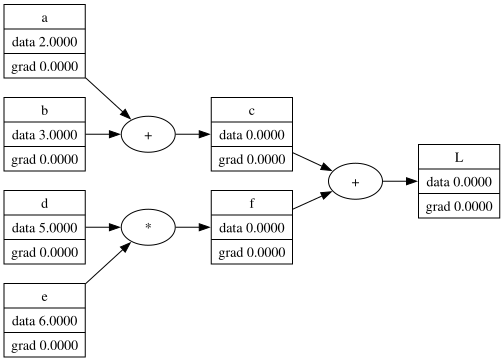

In [3]:
from graphviz import Digraph

def draw(root: Value) -> Digraph:
  dot = Digraph(graph_attr={'rankdir': 'LR'})
  seen = set()
  def build(v: Value):
    if id(v) in seen:
      return
    seen.add(id(v))
    dot.node(str(id(v)), f'{v.label} | data {v.data:.4f} | grad {v.grad:.4f}', shape='record')
    if v.op:
      dot.node(str(id(v)) + v.op, v.op)
      dot.edge(str(id(v)) + v.op, str(id(v)))
    for child in v.children:
      build(child)
      dot.edge(str(id(child)), str(id(v)) + v.op)
  build(root)
  return dot

draw(L)

In [4]:
L.forward()

35.0

In [5]:
# '''
# L = c + f
# c = a + b
# f = d * e
# '''

# '''
# dL/dL = 1
# '''
# L.grad = 1

# '''
# dL/dc = 1
# '''
# c.grad = 1

# '''
# dL/df = 1
# '''
# f.grad = 1

# '''
# dL/da = dL/dc * dc/da
#       = 1 * dc/da
#       = 1 * 1
# '''
# a.grad = 1

# '''
# dL/db = dL/dc * dc/db
#       = 1 * dc/db
#       = 1 * 1
# '''
# b.grad = 1

# '''
# dL/dd = dL/df * df/dd
#       = 1 * df/dd
#       = 1 * e.data
# '''
# d.grad = e.data

# '''
# dL/de = dL/df * df/de
#       = 1 * df/de
#       = 1 * d.data
# '''
# e.grad = d.data

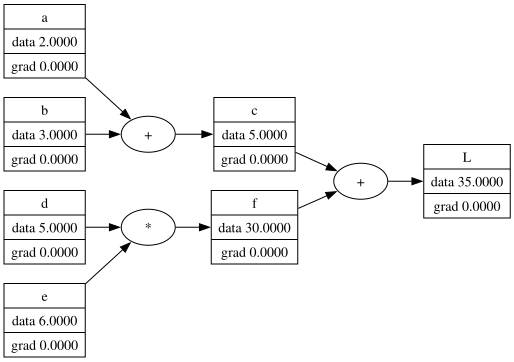

In [6]:
draw(L)

In [7]:
L.grad = 1.0
L.backward()

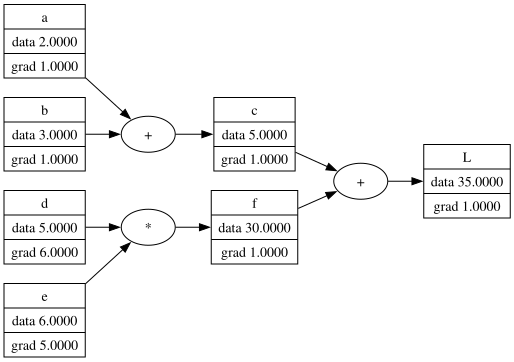

In [8]:
draw(L)

In [9]:
x = Value(3, label='x')
y = Value(label='y', children=[x, x], op='*')   # y = x * x

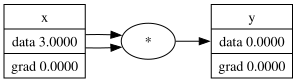

In [10]:
draw(y)

In [11]:
y.forward()

9.0

In [ ]:
y.grad = 1.0
y.backward()

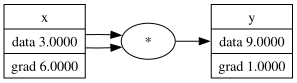

In [ ]:
draw(y)

In [14]:
assert x.grad == 6.0

In [ ]:
class Neuron:
  def __init__(
      self,
      weights: list[float],
      bias: float,
  ) -> None:
    self.weights = weights
    self.bias = bias

    # TODO: improve labels for when we have multiple Neurons
    self.weight_values = [Value(weight, label=f'w{i}') for i, weight in enumerate(self.weights)]
    self.bias_value = Value(self.bias, label='b')

  def forward(
      self,
      inputs: list[float],
  ) -> float:
    assert len(self.weights) == len(inputs)
    weight_nodes: list[Value] = []
    input_values = [Value(weight, label=f'x{i}') for i, weight in enumerate(self.weights)]
    zipped_values: list[tuple[Value, Value]] = zip(self.weight_values, input_values)
    for weight_value, input_value in zipped_values:
      weight_nodes.append(
          Value(
              label=weight_value.label + input_value.label,
              op='*',
              children=[weight_value, input_value],
          )
      )

    for node in weight_nodes + self.bias_value:
      # TODO: compose with new `Value(op='+')`s
      pass